# Lịch sử huấn luyện SEHTGNN và HTGNN (trắng–đen)

Notebook trực quan hóa `_sehtgnn1`, `_sehtgnn2` và `_htgnn1`–`_htgnn4`. Các kiểu nét và marker khác nhau giúp biểu đồ vẫn phân biệt được khi in trắng–đen.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("grayscale")
CM = 1 / 2.54
HISTORY_FIG_WIDTH_CM = 16
MODEL_HISTORY_HEIGHT_CM = 11.2
COMPARISON_HISTORY_HEIGHT_CM = 11.6
LEGEND_FONT_SIZE = 13
plt.rcParams.update({
    "font.family": "Times New Roman",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "font.size": 13,
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "grid.color": "0.80",
    "grid.linestyle": ":",
    "grid.linewidth": 0.7,
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

In [2]:
# Notebook có thể chạy từ thư mục result/ hoặc từ thư mục gốc dự án.
RESULT_DIR = Path.cwd()
if not (RESULT_DIR / "_htgnn1").exists():
    RESULT_DIR = RESULT_DIR / "result"

MODEL_FILES = {
    "SEHTGNN-1": RESULT_DIR / "_sehtgnn1" / "sehtgnn_train_history.csv",
    "SEHTGNN-2": RESULT_DIR / "_sehtgnn2" / "sehtgnn_train_history.csv",
    "HTGNN-1": RESULT_DIR / "_htgnn1" / "htgnn_train_history.csv",
    "HTGNN-2": RESULT_DIR / "_htgnn2" / "htgnn_train_history.csv",
    "HTGNN-3": RESULT_DIR / "_htgnn3" / "htgnn_train_history.csv",
    "HTGNN-4": RESULT_DIR / "_htgnn4" / "htgnn_train_history.csv",
}

missing = [str(path) for path in MODEL_FILES.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Không tìm thấy:\n" + "\n".join(missing))

histories = {name: pd.read_csv(path) for name, path in MODEL_FILES.items()}
[(name, len(data)) for name, data in histories.items()]

[('SEHTGNN-1', 13),
 ('SEHTGNN-2', 12),
 ('HTGNN-1', 41),
 ('HTGNN-2', 47),
 ('HTGNN-3', 97),
 ('HTGNN-4', 84)]

## Lịch sử huấn luyện của từng model

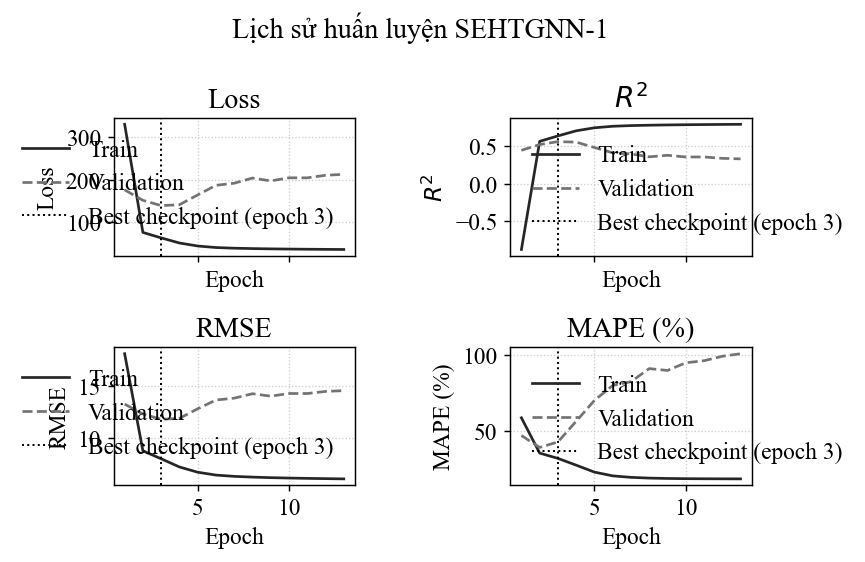

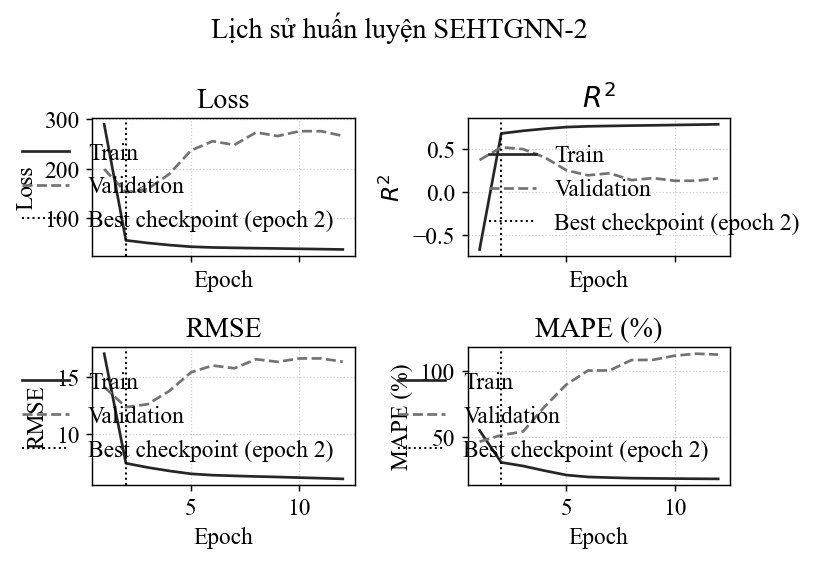

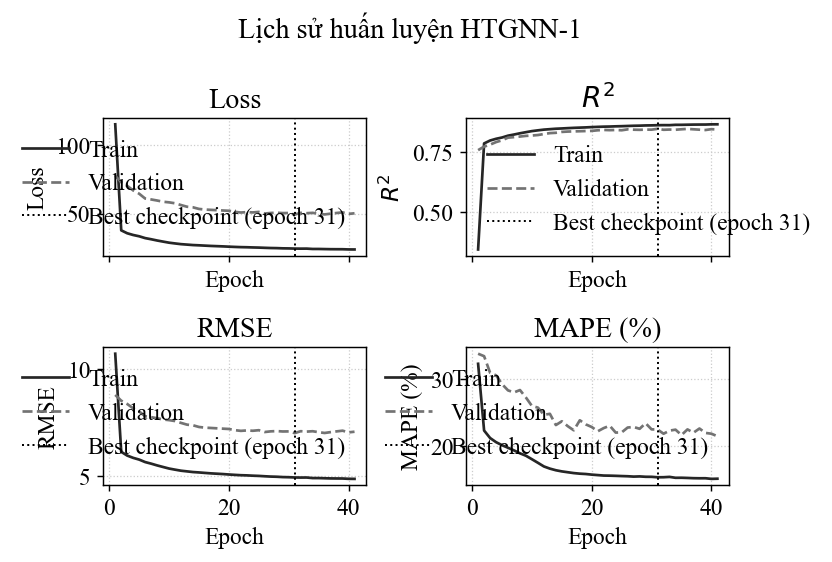

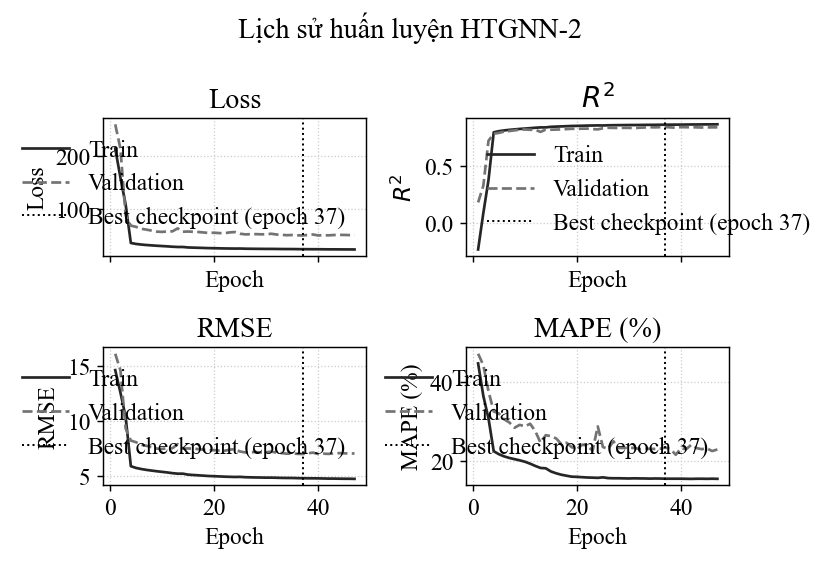

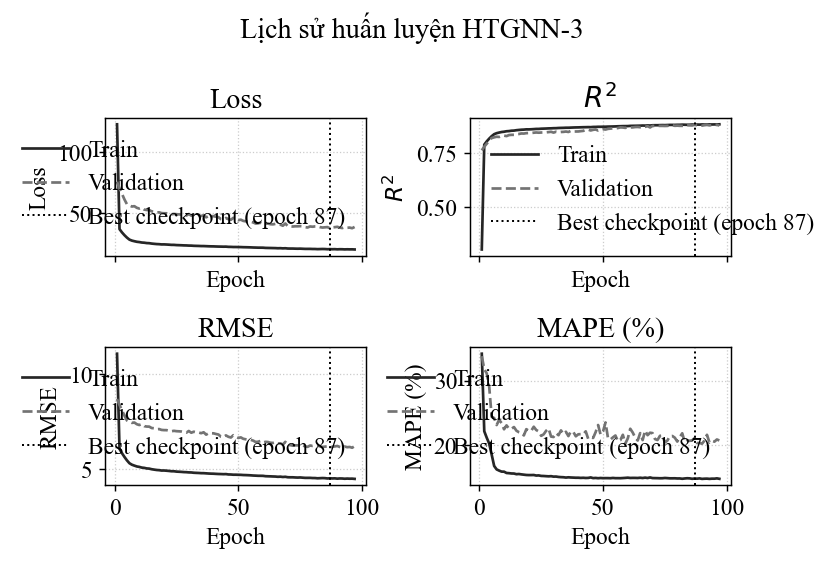

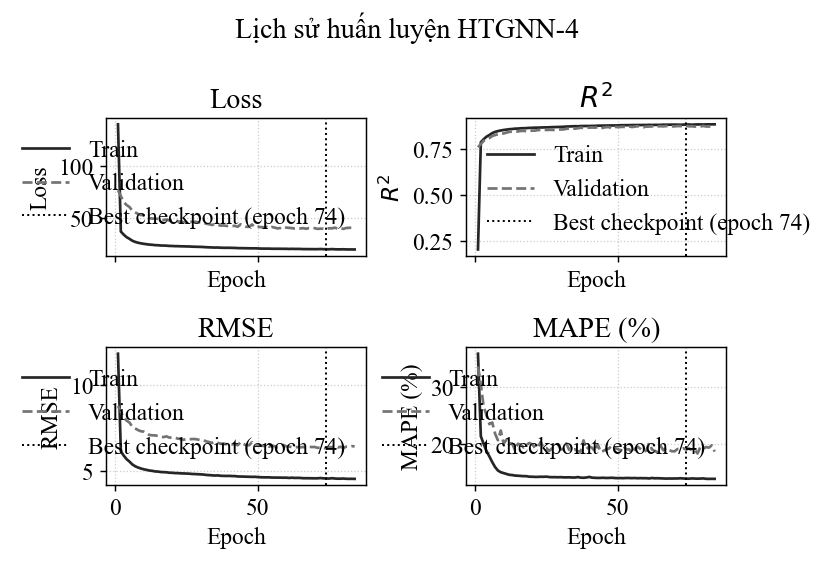

In [3]:
METRICS = [
    ("loss", "Loss"),
    ("r2", r"$R^2$"),
    ("rmse", "RMSE"),
    ("mape", "MAPE (%)"),
]

def plot_model_history(name, data, save=False):
    epochs = data["epoch"].to_numpy()
    best_idx = data["val_rmse"].idxmin()
    best_epoch = int(data.loc[best_idx, "epoch"])

    fig, axes = plt.subplots(
        2, 2,
        figsize=(HISTORY_FIG_WIDTH_CM * CM, MODEL_HISTORY_HEIGHT_CM * CM),
        sharex=True,
    )
    for ax, (key, ylabel) in zip(axes.flat, METRICS):
        ax.plot(epochs, data[f"train_{key}"], color="0.15",
                linestyle="-", linewidth=1.5, label="Train")
        ax.plot(epochs, data[f"val_{key}"], color="0.45",
                linestyle="--", linewidth=1.5, label="Validation")
        ax.axvline(best_epoch, color="black", linestyle=":", linewidth=1.1,
                   label=f"Best checkpoint (epoch {best_epoch})")
        ax.set_title(ylabel)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.grid(True)
        ax.legend(frameon=False, fontsize=LEGEND_FONT_SIZE)

    fig.suptitle(f"Lịch sử huấn luyện {name}")
    fig.tight_layout()
    if save:
        output = RESULT_DIR / f"{name.lower()}_history_bw.png"
        fig.savefig(output)
        print(f"Đã lưu: {output}")
    plt.show()

for model_name, history in histories.items():
    plot_model_history(model_name, history, save=False)

## So sánh validation giữa 6 model

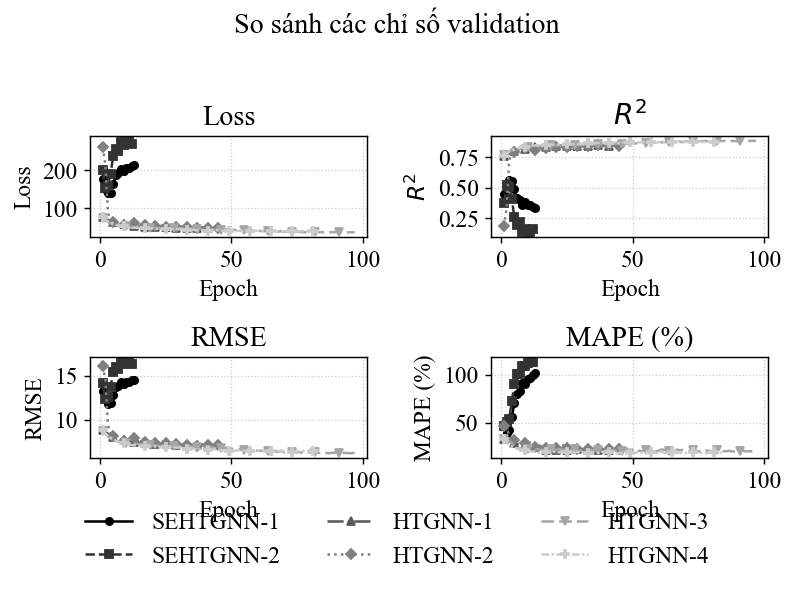

In [4]:
LINE_STYLES = {
    "SEHTGNN-1": dict(color="0.00", linestyle="-",  marker="o"),
    "SEHTGNN-2": dict(color="0.20", linestyle="--", marker="s"),
    "HTGNN-1":   dict(color="0.35", linestyle="-.", marker="^"),
    "HTGNN-2":   dict(color="0.50", linestyle=":",  marker="D"),
    "HTGNN-3":   dict(color="0.65", linestyle=(0, (5, 2)), marker="v"),
    "HTGNN-4":   dict(color="0.80", linestyle=(0, (3, 1, 1, 1)), marker="P"),
}

fig, axes = plt.subplots(
    2, 2,
    figsize=(HISTORY_FIG_WIDTH_CM * CM, COMPARISON_HISTORY_HEIGHT_CM * CM),
)
for ax, (key, ylabel) in zip(axes.flat, METRICS):
    for name, data in histories.items():
        style = LINE_STYLES[name]
        markevery = max(len(data) // 10, 1)
        ax.plot(
            data["epoch"], data[f"val_{key}"], label=name,
            linewidth=1.4, markersize=4, markevery=markevery, **style
        )
    ax.set_title(ylabel)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False,
           fontsize=LEGEND_FONT_SIZE,
           bbox_to_anchor=(0.5, 0.01))
fig.suptitle("So sánh các chỉ số validation")
fig.tight_layout(rect=(0, 0.08, 1, 0.96))
plt.show()

# Bỏ dấu # ở dòng dưới nếu muốn xuất hình dùng trong báo cáo.
# fig.savefig(RESULT_DIR / "validation_comparison_bw.png")

## Bảng epoch tốt nhất và chỉ số validation tại checkpoint

In [5]:
summary_rows = []
for name, data in histories.items():
    best_row = data.loc[data["val_rmse"].idxmin()]
    summary_rows.append({
        "Model": name,
        "Epoch tốt nhất": int(best_row["epoch"]),
        "Val RMSE": best_row["val_rmse"],
        "Val MAPE (%)": best_row["val_mape"],
        "Val R²": best_row["val_r2"],
    })

summary = pd.DataFrame(summary_rows).set_index("Model")
summary.round(4)

,Epoch tốt nhất,Val RMSE,Val MAPE (%),Val R²
Model,,,,
SEHTGNN-1,3,11.7866,42.9168,0.5638
SEHTGNN-2,2,12.3491,51.2948,0.5212
HTGNN-1,31,7.0213,22.4741,0.8452
HTGNN-2,37,7.0276,23.4468,0.8449
HTGNN-3,87,6.1287,21.1187,0.8821
HTGNN-4,74,6.2898,19.0821,0.8758
